In [1]:
import pandas as pd

df = pd.read_csv("verses_cleaned_no_thanks_nom.csv")

print(df.head())
print(df.columns)
print(len(df))


   song_id  author  verse_order  \
0        1  $ierra            1   
1        2    2020            1   
2        3      2K            1   
3        4    2sty            1   
4        7   4tune            1   

                                                text  num_lines  char_count  \
0  #hot16challenge2\nWokoło sami aktorzy zgrywają...         39        1716   
1  2020 #hot16challange\nW 2-20 miał wyjść mój ra...         18         594   
2  #Hot16Challenge2\nZapierdalam ciężko, bo się n...         17         744   
3  #hot16challenge2\nDługo mnie nie było, bo zała...         19         622   
4  #hot16challenge2\nIch komm' in den Raum und du...         17         967   

                                          text_clean  removed_lines  \
0  Wokoło sami aktorzy zgrywają mafiozów jak Robe...              1   
1  2020 #hot16challange\nW 2-20 miał wyjść mój ra...              0   
2  Zapierdalam ciężko, bo się nie lubię przedstaw...              1   
3  Długo mnie nie było, bo zał

In [2]:
import pandas as pd

df = pd.read_csv("verses_cleaned_no_thanks_nom.csv")

df["tokens"] = df["text_clean"].str.split()

df[["text_clean", "tokens"]].head()


,text_clean,tokens
0,Wokoło sami aktorzy zgrywają mafiozów jak Robe...,"[Wokoło, sami, aktorzy, zgrywają, mafiozów, ja..."
1,2020 #hot16challange\nW 2-20 miał wyjść mój ra...,"[2020, #hot16challange, W, 2-20, miał, wyjść, ..."
2,"Zapierdalam ciężko, bo się nie lubię przedstaw...","[Zapierdalam, ciężko,, bo, się, nie, lubię, pr..."
3,"Długo mnie nie było, bo załatwiałem sprawy\nLa...","[Długo, mnie, nie, było,, bo, załatwiałem, spr..."
4,"Ich komm' in den Raum und du weißt, gleich wir...","[Ich, komm', in, den, Raum, und, du, weißt,, g..."


In [3]:
df["n_tokens"] = df["tokens"].apply(len)

df["n_tokens"].describe()


count     734.000000
mean      194.955041
std       294.309467
min         1.000000
25%       124.000000
50%       154.000000
75%       207.500000
max      4607.000000
Name: n_tokens, dtype: float64

In [4]:
lex = pd.read_excel("slownik.xlsx")
lex.head()
lex.columns


/home/korodes7/ProjektFinal/venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Index(['No.', 'BAWL_word', 'NAWL_word', 'BE_N_all', 'hap_M_all', 'hap_SD_all',
       'ang_M_all', 'ang_SD_all', 'sad_M_all', 'sad_SD_all', 'fea_M_all',
       'fea_SD_all', 'dis_M_all', 'dis_SD_all', 'BE_N_women', 'hap_M_women',
       'hap_SD_women', 'ang_M_women', 'ang_SD_women', 'sad_M_women',
       'sad_SD_women', 'fea_M_women', 'fea_SD_women', 'dis_M_women',
       'dis_SD_women', 'BE_N_men', 'hap_M_men', 'hap_SD_men', 'ang_M_men',
       'ang_SD_men', 'sad_M_men', 'sad_SD_men', 'fea_M_men', 'fea_SD_men',
       'dis_M_men', 'dis_SD_men', 'DENN_BAWL', 'Briesemeister_liberal',
       'Briesemeister_conservative', 'Mikels', 'Mikels_blended', 'ED_class'],
      dtype='str')

In [5]:
import pandas as pd

lex = pd.read_excel("slownik.xlsx")

lex = lex[["NAWL_word", "hap_M_all", "ang_M_all", "sad_M_all", "fea_M_all", "dis_M_all"]].copy()
lex["lemma"] = lex["NAWL_word"].str.lower().str.strip()

lex["emo_intensity"] = lex[
    ["hap_M_all", "ang_M_all", "sad_M_all", "fea_M_all", "dis_M_all"]
].mean(axis=1, skipna=True)

emo_dict = dict(zip(lex["lemma"], lex["emo_intensity"]))


/home/korodes7/ProjektFinal/venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [6]:
df["tokens"] = df["text_clean"].str.split()
df["n_tokens"] = df["tokens"].apply(len)


In [7]:
def introspection_score(tokens):
    if len(tokens) == 0:
        return 0.0

    score = sum(emo_dict.get(t, 0.0) for t in tokens)
    return score / len(tokens)

df["introspection"] = df["tokens"].apply(introspection_score)


In [8]:
def power_score(tokens):
    if len(tokens) == 0:
        return 0.0

    verb_like = [t for t in tokens if t.endswith(("c", "ć", "ć", "em", "am", "am"))]
    return len(verb_like) / len(tokens)

df["power"] = df["tokens"].apply(power_score)


In [9]:
df.sort_values("introspection", ascending=False)[
    ["artist", "song", "introspection", "power", "typ_narracji"]
].head(10)

KeyError: "['artist', 'song', 'typ_narracji'] not in index"

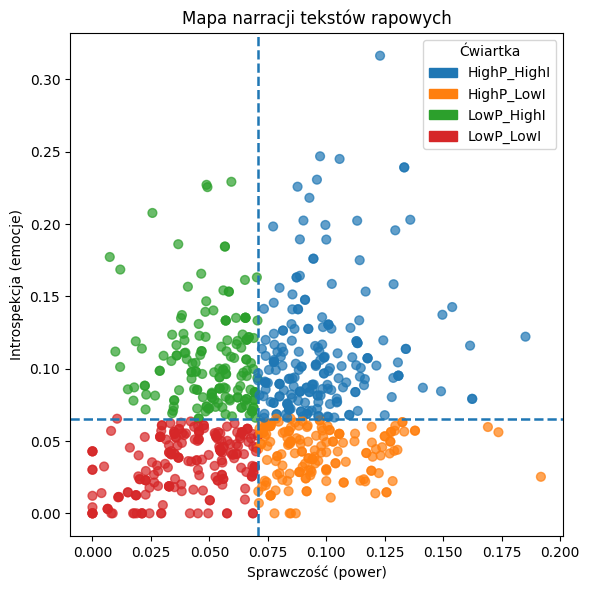

In [11]:
import matplotlib.pyplot as plt

# Wylicz mediany
p_med = df["power"].median()
i_med = df["introspection"].median()

# Stwórz etykiety ćwiartek względem median
conditions = [
    (df["power"] >= p_med) & (df["introspection"] >= i_med),
    (df["power"] >= p_med) & (df["introspection"] < i_med),
    (df["power"] < p_med) & (df["introspection"] >= i_med),
    (df["power"] < p_med) & (df["introspection"] < i_med),
]
labels = ["HighP_HighI", "HighP_LowI", "LowP_HighI", "LowP_LowI"]

import numpy as np
quad = np.select(conditions, labels, default="Unknown")

# Kolory dla ćwiartek
color_map = {
    "HighP_HighI": "#1f77b4",  # niebieski
    "HighP_LowI": "#ff7f0e",   # pomarańczowy
    "LowP_HighI": "#2ca02c",   # zielony
    "LowP_LowI": "#d62728",    # czerwony
    "Unknown": "#7f7f7f",
}
colors = [color_map[c] for c in quad]

plt.figure(figsize=(6,6))
plt.scatter(df["power"], df["introspection"], alpha=0.7, s=40, c=colors)
# linie median
plt.axvline(p_med, linestyle="--", color="#1f77b4", linewidth=1.8)
plt.axhline(i_med, linestyle="--", color="#1f77b4", linewidth=1.8)

plt.xlabel("Sprawczość (power)")
plt.ylabel("Introspekcja (emocje)")
plt.title("Mapa narracji tekstów rapowych")

# Legendę zbudujemy ręcznie
from matplotlib.patches import Patch
handles = [Patch(color=color_map[l], label=l) for l in labels]
plt.legend(handles=handles, title="Ćwiartka", loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
quadrants = (
    df["typ_narracji"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

quadrants


typ_narracji
obserwacja_dystans        27.9
emocjonalna_sprawczosc    27.9
narracja_akcji            22.1
narracja_emocji           22.1
Name: proportion, dtype: float64

In [ ]:
strategy_summary = (
    df.groupby("typ_narracji", as_index=False)
      .agg(
          mean_power=("power", "mean"),
          mean_introspection=("introspection", "mean"),
          n_texts=("power", "size")
      )
      .sort_values("mean_introspection", ascending=False)
)

strategy_summary


,typ_narracji,mean_power,mean_introspection,n_texts
0,emocjonalna_sprawczosc,0.097935,0.109989,205
2,narracja_emocji,0.050844,0.105188,162
1,narracja_akcji,0.097255,0.041541,162
3,obserwacja_dystans,0.040348,0.034330,205


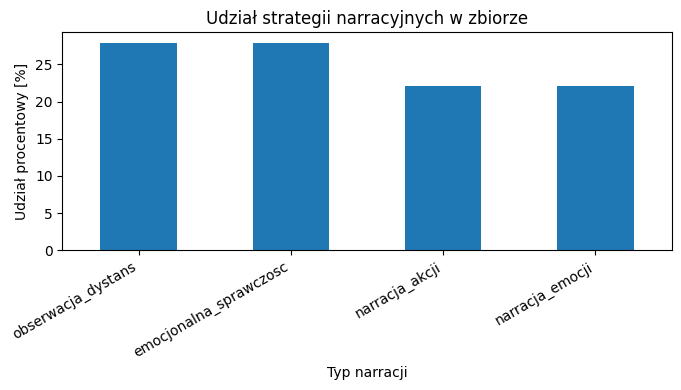

In [ ]:
import matplotlib.pyplot as plt

quad_pct = (
    df["typ_narracji"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

plt.figure(figsize=(7,4))
quad_pct.plot(kind="bar")
plt.ylabel("Udział procentowy [%]")
plt.xlabel("Typ narracji")
plt.title("Udział strategii narracyjnych w zbiorze")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


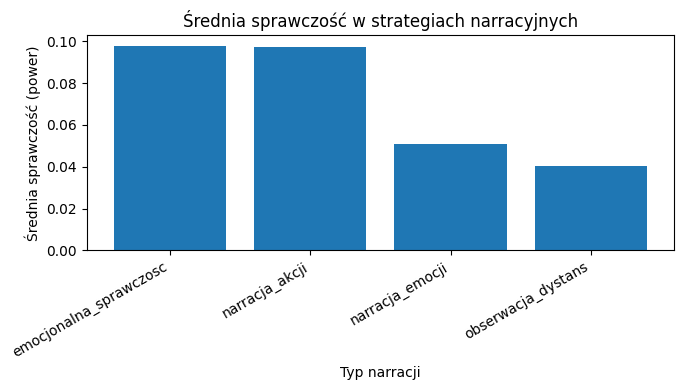

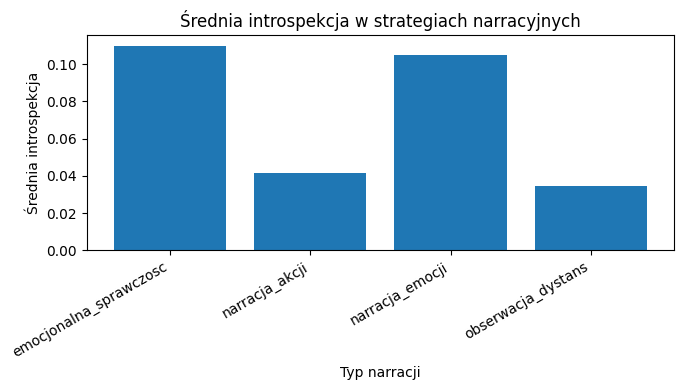

In [ ]:
strategy_summary = (
    df.groupby("typ_narracji", as_index=False)
      .agg(
          mean_power=("power", "mean"),
          mean_introspection=("introspection", "mean")
      )
)

# --- WYKRES 1: średnia sprawczość ---
plt.figure(figsize=(7,4))
plt.bar(strategy_summary["typ_narracji"], strategy_summary["mean_power"])
plt.ylabel("Średnia sprawczość (power)")
plt.xlabel("Typ narracji")
plt.title("Średnia sprawczość w strategiach narracyjnych")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- WYKRES 2: średnia introspekcja ---
plt.figure(figsize=(7,4))
plt.bar(strategy_summary["typ_narracji"], strategy_summary["mean_introspection"])
plt.ylabel("Średnia introspekcja")
plt.xlabel("Typ narracji")
plt.title("Średnia introspekcja w strategiach narracyjnych")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


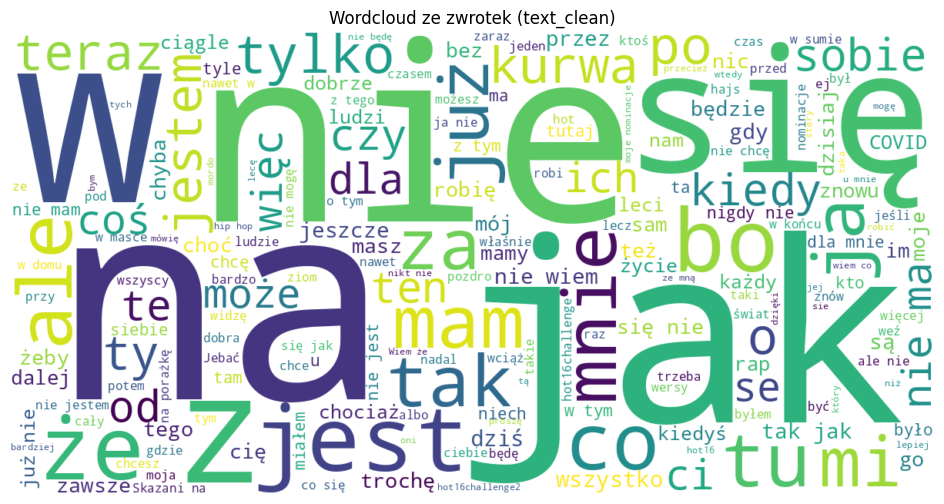

In [12]:
# --- WORDCLOUD: najprościej ze wszystkich zwrotek ---
import pandas as pd
import matplotlib.pyplot as plt

try:
    from wordcloud import WordCloud
except ImportError:
    raise ImportError("Brakuje pakietu 'wordcloud'. Zainstaluj: pip install wordcloud")

# Wczytaj dane (używamy tej samej ścieżki co wcześniej)
df = pd.read_csv("verses_cleaned_no_thanks_nom.csv")

# Scal wszystkie teksty w jeden ciąg
text_all = " ".join(df["text_clean"].astype(str).tolist())

# Generuj wordcloud
wc = WordCloud(width=1200, height=600, background_color="white", max_words=200).generate(text_all)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud ze zwrotek (text_clean)")
plt.show()
